In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [2]:
special = [ {"data": "gender", "loss": 'contrastive', 'alg':'logreg', 'path': "gender_output_2025-10-11 13:17:30.574798_ContrastiveLoss_gru_logreg"}]

In [1]:
full_exps = [{"data": 'age', 'loss': 'contrastive', 'alg': 'catboost', 'path': "outputs/age_pred_output_2025-10-10 14:37:35.506749_ContrastiveLoss_gru_catboost"},
           {"data": 'age', 'loss': 'contrastive', 'alg': 'mlp', 'path': "outputs/age_pred_output_2025-10-11 15:33:41.849670_ContrastiveLoss_gru_mlp"},
          {"data": "gender", "loss": 'contrastive', 'alg':'logreg', 'path': "outputs/gender_output_2025-10-10 13:22:49.999835_ContrastiveLoss_gru_logreg"},
           {"data": "gender", "loss": 'contrastive', 'alg':'mlp', 'path': "outputs/gender_output_2025-10-09 11:31:59.174931_ContrastiveLoss_gru_mlp"},
           {"data": "gender", "loss": 'barlow_twins', 'alg':'catboost', 'path': "outputs/gender_output_2025-10-08 23:29:01.030695_BarlowTwinsLoss_gru_catboost"},
           {"data": "gender", "loss": "vicreg", 'alg': "catboost", 'path':"outputs/gender_output_2025-10-08 10:26:11.109161_VicregLoss_gru_catboost"},
           {"data": "gender", "loss": "contrastive", 'alg': "catboost", 'path':"outputs/gender_output_2025-10-07 19:53:20.141369_ContrastiveLoss_gru_catboost"},
            ]
            #{"data": "age", "loss": "barlow_twins", 'alg': "catboost", 'path':"outputs/age_pred_output_2025-10-14 04:52:36.352614_BarlowTwinsLoss_gru_catboost"}]
            #{"data": "gender", "loss": "barlow_twins", 'alg': "catboost", 'path':"RECYCLE.BIN/output_2025-10-05 22:08:41.254649 BarlowTwinsLoss default catboost downstream multimodal"},
             #{"data": "gender", "loss": "contrastive", 'alg': "catboost", 'path':"RECYCLE.BIN/output_2025-10-05 17:04:39.041865 ContrastiveLoss default catboost downstream multimodal"},
             #{"data": "gender", "loss": "contrastive", 'alg': "catboost", "path":"RECYCLE.BIN/gender_mm_contrastive_old_catboost_30"}]
           
           
           
           

In [4]:
for i in range(len(full_exps)):
    file_paths = sorted(glob.glob(f"../{full_exps[i]['path']}/out_*.csv"))
    all_dfs = []
    #print(full_exps[i]['path'], file_paths)
    for path in file_paths:
        df = pd.read_csv(path)
        df["sample_fraction"] = float(path.split("_")[-1].replace(".csv", ""))
        all_dfs.append(df)
    
    # Объединяем в один DataFrame
    full_exps[i]['df_all'] = pd.concat(all_dfs, ignore_index=True)

In [5]:
#necessary for indexing
for i in range(len(full_exps)):
    metric_columns = [col for col in full_exps[i]['df_all'].columns if col.startswith("metric_")] \
+ ['recall_topk']
    full_exps[i]['metric_columns'] = metric_columns
    full_exps[i]['df_all'] = full_exps[i]['df_all'].set_index('checkpoint')

In [6]:
funcs = {'linear': lambda metric, acc, sign: metric.corr(acc) * sign,
 'rank': lambda metric, acc, sign: metric.corr(acc, method='spearman') * sign,
 'accuracy': lambda metric, acc, sign: acc.values[
                    np.argmax(sign * metric.values)]
}
                

In [7]:
params_cols=['batch_size', 
             'learning_rate', 
             'split_count',
             'cnt_min', 'cnt_max', 'embedding_dim', 
             'category_embedding_dim', 
             'hidden_size', 
             'loss', 
             'rnn_encoder_type']

In [8]:
import numpy as np
from scipy.stats import spearmanr

from collections import defaultdict

for i in range(len(full_exps)):
    # groupby type : corelation or acc : value
    corr_records = defaultdict(lambda: defaultdict(list))
    
    df_all = full_exps[i]['df_all'].dropna()
    # print(df_all.shape, df_all.dropna().shape,  df_all.dropna()['sample_fraction'].unique())
    # print(full_exps[i]['loss'], full_exps[i]['data'])
    # print(df_all["metric_ripser_sum_H0"].dropna().shape)
    # print(df_all.dropna()['roc_auc'])
    # print(df_all["metric_rankme"].dropna().shape)
    df_all['checkpoint'] = df_all.index.values
    runs = df_all['checkpoint'].values
    for j in range(df_all.shape[0]):
        runs[j] = runs[j][:-10]
    
    df_all['runs'] = runs

    #for parameters indexing
    other_params = {}
    for param in params_cols:
        curr_other_params = [p for p in params_cols if p != param]
        combined = "_".join(curr_other_params)
        other_params[param] = combined
        df_all[combined] = df_all[curr_other_params].astype(str).sum(axis=1)
        
    # Вычисляем корреляцию с accuracy для каждой метрики при каждом sample_fraction
    for frac in sorted(df_all['sample_fraction'].unique()):
        sub = df_all[df_all['sample_fraction'] == frac]
        
        #sub = sub[sub['epoch_num'] == sub['early_stop_epoch']]
        for metric in full_exps[i]['metric_columns']:
            sign = np.sign(df_all[df_all['sample_fraction'] > 0.95][metric].corr(
                    sub['roc_auc'], method='spearman'))

            #OVERALL CORRELATION OVER ALL RUNS
            if sub[metric].nunique() > 1:  # нужно хотя бы 2 уникальных значения для корреляции
                for k, v in funcs.items():
                    corr_records['all'][k].append({
                        "sample_fraction": frac,
                        "metric": metric,
                        "correlation": v(sub[metric], sub['roc_auc'], sign)
                    })
                    
            #CORRELATTION OF BEST CHECKPOINT
            for check, check_data in sub.groupby('runs'):        
                if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique() > 1:
                    for k, v in funcs.items():
                        corr_records['checkpoint'][k].append({
                            "sample_fraction": frac,
                            "metric": metric,
                            "correlation": v(check_data[metric], check_data['roc_auc'], sign)
                        })
            #CORRELATION PER PARAM
            for param in params_cols:
                combined = other_params[param]
                for check, check_data in sub.groupby(combined):   
                    if check_data[param].nunique() <= 1:
                        continue
                    if check_data[metric].nunique() > 1 and check_data['accuracy'].nunique()> 1:
                        for k, v in funcs.items():
                            corr_records[param][k].append({
                                "sample_fraction": frac,
                                "metric": metric,
                                "correlation": v(check_data[metric], check_data['roc_auc'], sign)
                            })                        

    for group, group_recs in corr_records.items():
        for k, curr_rec in group_recs.items():
            corr_df = pd.DataFrame(curr_rec)
            curr_name = f'corr_{k}_{group}'
            full_exps[i][f'{curr_name}_df'] = corr_df
            full_exps[i][curr_name] = {}
            full_exps[i][curr_name]['small'] = corr_df[corr_df['sample_fraction'] < 0.4].groupby("metric")["correlation"].mean().sort_values(ascending=False)
            full_exps[i][curr_name]['all'] = corr_df[corr_df['sample_fraction'] > 0.0].groupby("metric")["correlation"].mean().sort_values(ascending=False)
            full_exps[i][curr_name]['full'] = corr_df[corr_df['sample_fraction'] > 0.8].groupby("metric")["correlation"].mean().sort_values(ascending=False)
    

In [8]:

from collections import defaultdict
corr_all_full = defaultdict(lambda: defaultdict(list))
exp_keys = [k for (k, v) in full_exps[0].items() if (type(v) is str)]
print(exp_keys)
corr_grouped = defaultdict(
    lambda: defaultdict(
    lambda: defaultdict(
    lambda: defaultdict(
    lambda: defaultdict(
        lambda: defaultdict(list))))))

for i in range(len(full_exps)):
    for corr_type in funcs.keys():
        for group_type in (['all', 'checkpoint'] + params_cols):
            curr_name = f'corr_{corr_type}_{group_type}'
            if not(curr_name in full_exps[i]):
                continue
            for s in full_exps[i][curr_name].keys():
                corr_all_full[group_type][corr_type].append(full_exps[i][curr_name][s])
                for k in exp_keys:
                    corr_grouped[group_type][s][corr_type][k][full_exps[i][k]][full_exps[i]['data']].append(
                        full_exps[i][curr_name][s])
                    
for group_type in  (['all', 'checkpoint'] + params_cols):
    for corr_type in funcs.keys():
        if not (corr_all_full[group_type][corr_type]):
            continue
        corr_all_full[group_type][corr_type] = pd.concat(
            corr_all_full[group_type][corr_type], axis=1).mean(axis=1).sort_values(
            ascending=False)
        print(group_type, corr_type, corr_all_full[group_type][corr_type])

['data', 'loss', 'alg', 'path']


In [11]:
def filter_ripser(df):
    if len(df.shape) > 1:
        old_cols = df.columns
    else:
        old_cols = df.index
        
    new_cols = [col for col in old_cols 
                    if not('ripser' in col or col == "recall_topk") #specific metric for CoLES
                or 
                    col in ['metric_ripser_sum_H0_norm0.9', 'metric_ripser_sum_H0_norm0.99']]
    new_df = df[new_cols]
    return new_df.rename(index={col: col[7:] for col in new_df.index if 'metric' in col})

    

In [12]:
#print(list(corr_records.keys()))
for corr_type  in funcs.keys():
    #if corr_type == 'linear':
    #    continue
    print('================')
    print("quality type", corr_type)
    for group_type in corr_grouped.keys():#['all', 'checkpoint']:
        print('*****************')
        print("grouping by", group_type)
        for s in ['full']:#, 'all', 'small']:
            print('+++++++++++++++')
            print('sampling', s)
            for k in exp_keys:
                if k == 'path':
                    continue
                print('----------------------')
                print('experiment type', k)
                mean_corr = []
                for k1 in corr_grouped[group_type][s][corr_type][k].keys():
                    per_data = []
                    for d_k in corr_grouped[group_type][s][corr_type][k][k1].keys():
                        curr_corr = pd.concat(corr_grouped[group_type][s][corr_type][k][k1][d_k], axis=1).mean(axis=1).sort_values(ascending=False)
                        per_data.append(curr_corr)                        
                    
                    curr_corr = pd.concat(per_data, axis=1).mean(axis=1)    
                    print(f"Datasets num {len(per_data)}", k1, 
                          filter_ripser(curr_corr.sort_values(ascending=False)))
                    if len(per_data) > 1:
                        mean_corr.append(curr_corr)
                if len(mean_corr) > 1:
                    print("quality type", corr_type, 
                          "grouping by", group_type, 
                          'sampling', s,
                         'experiment type', k)
                    print(filter_ripser(
                        pd.concat(mean_corr, axis=1).mean(axis=1).sort_values(ascending=False)))

quality type linear
quality type rank
quality type accuracy


/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


batch_size


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


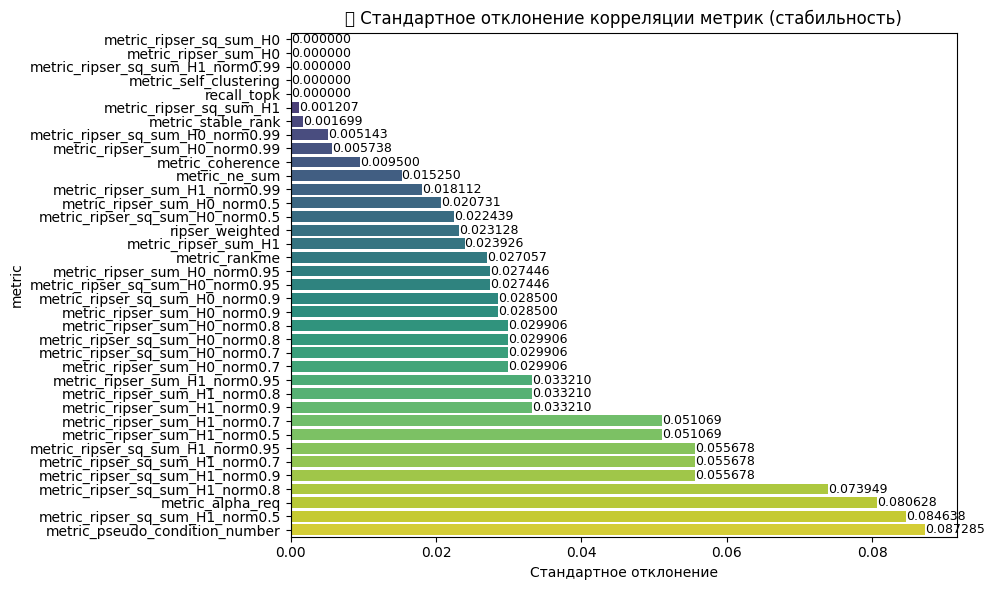

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


learning_rate


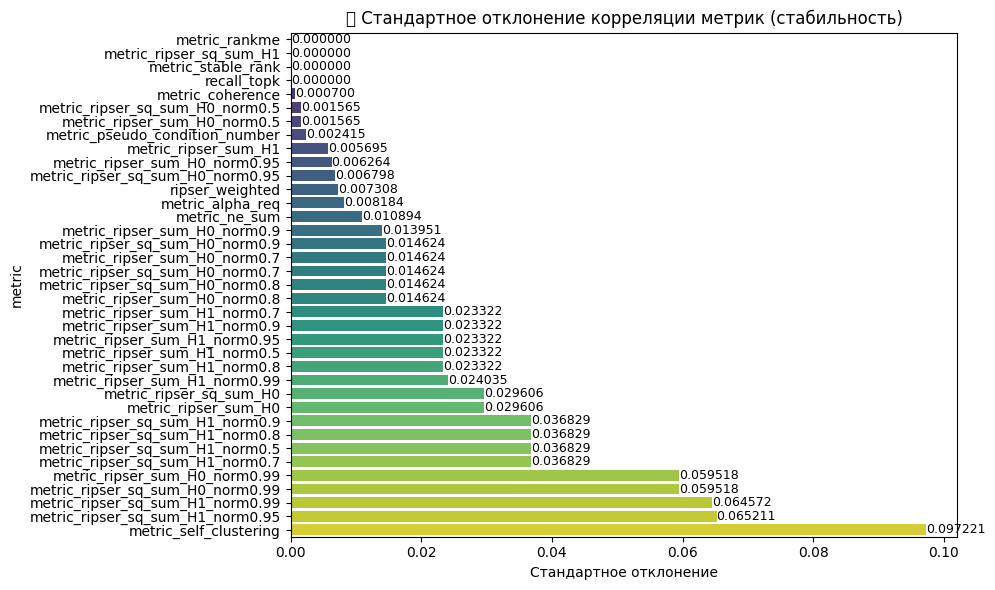

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")


split_count


/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


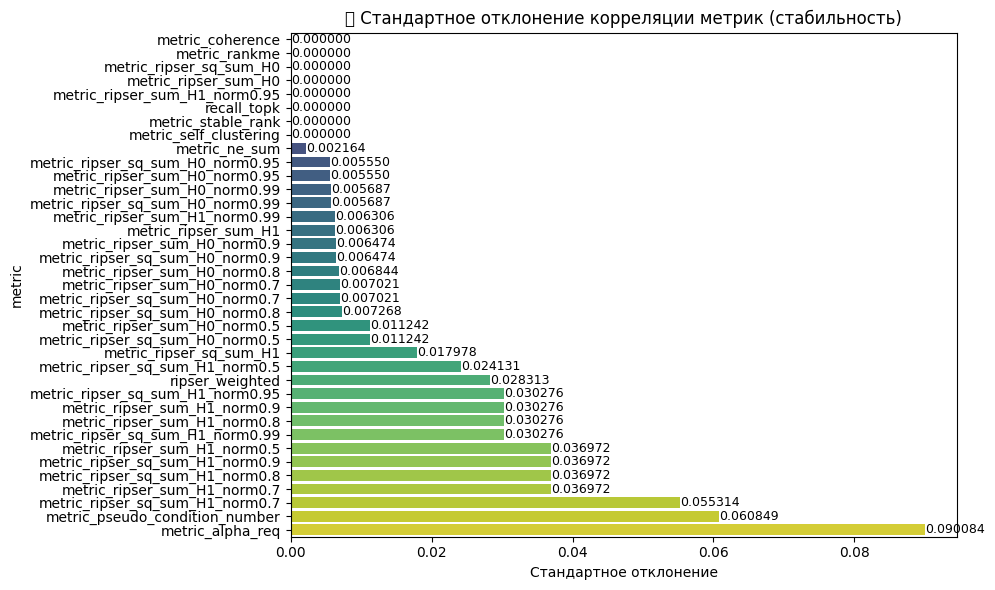

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


cnt_min


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


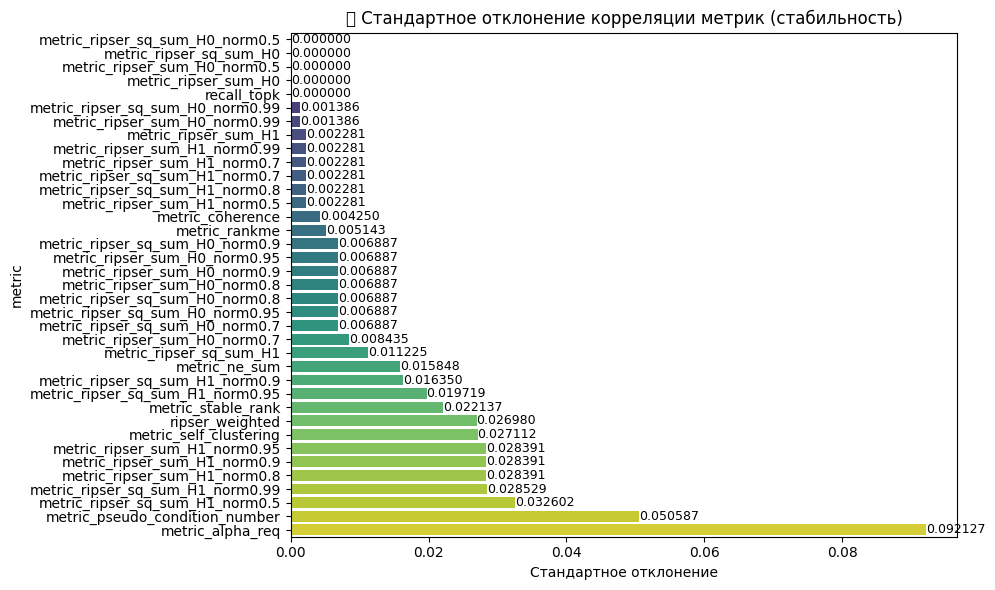

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


cnt_max


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


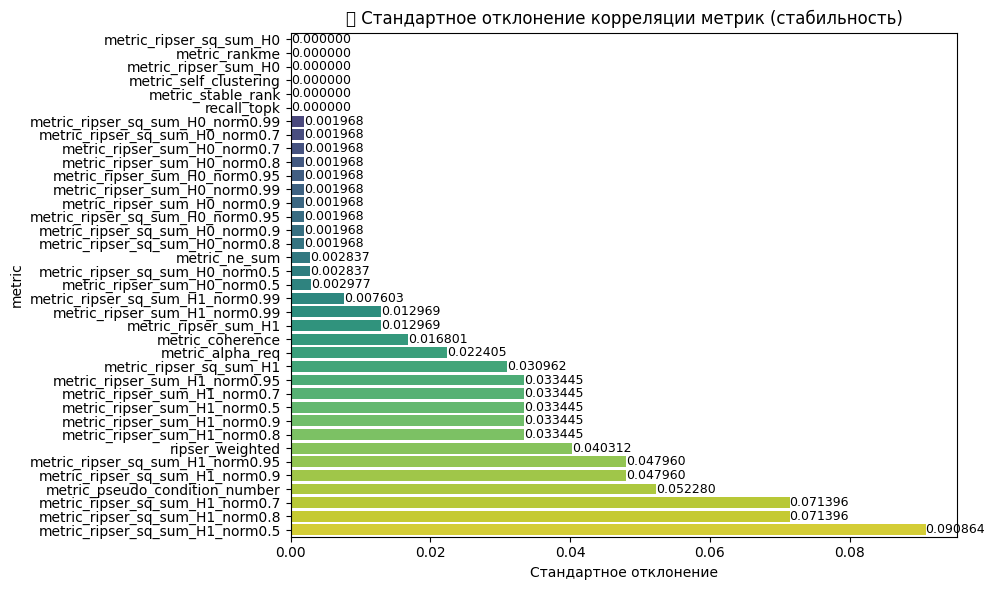

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


embedding_dim


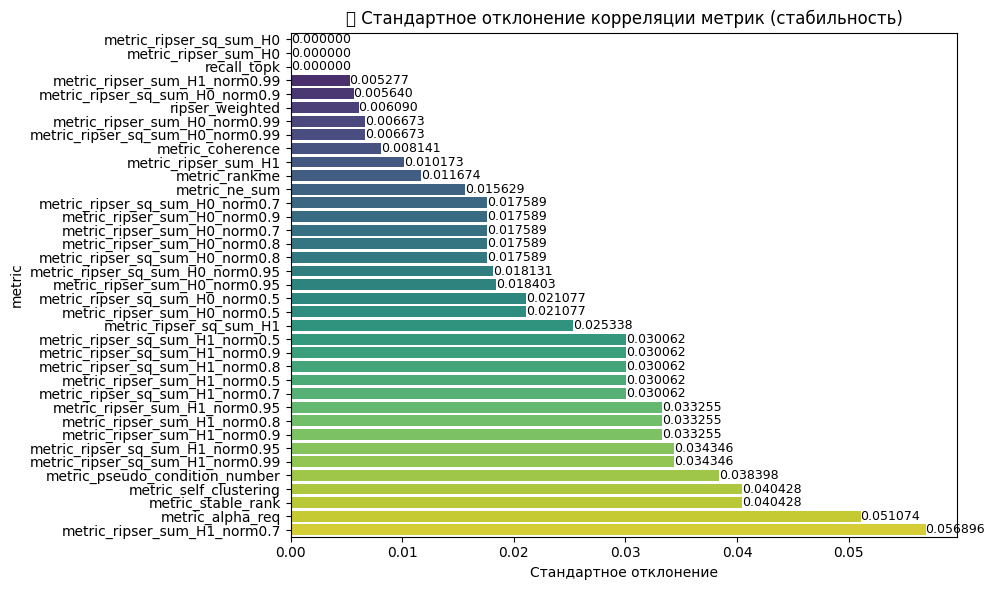

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


category_embedding_dim


/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


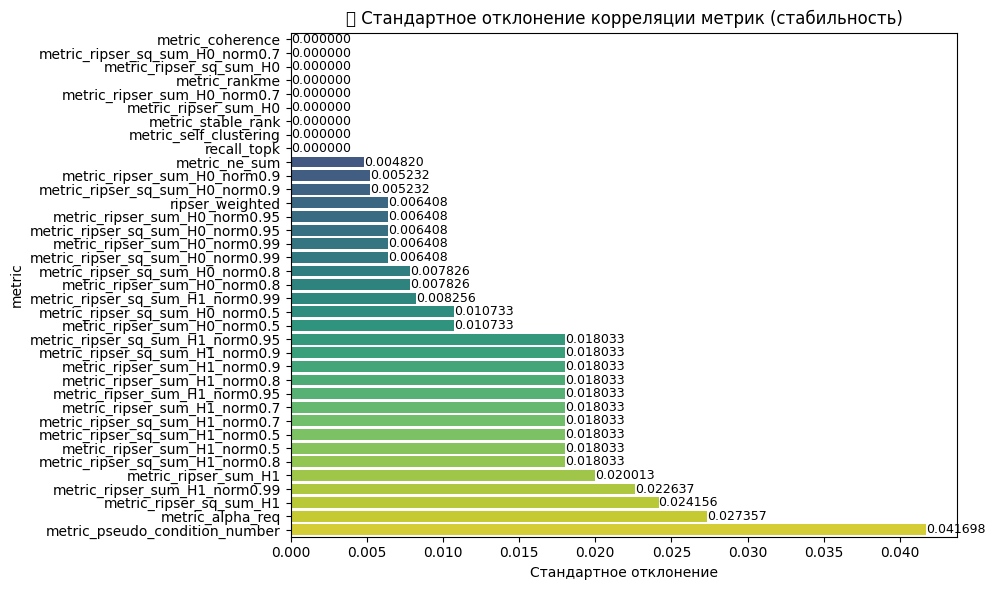

/tmp/ipykernel_3412665/859362125.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
/tmp/ipykernel_3412665/859362125.py:11: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/dpetrovitch/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


hidden_size


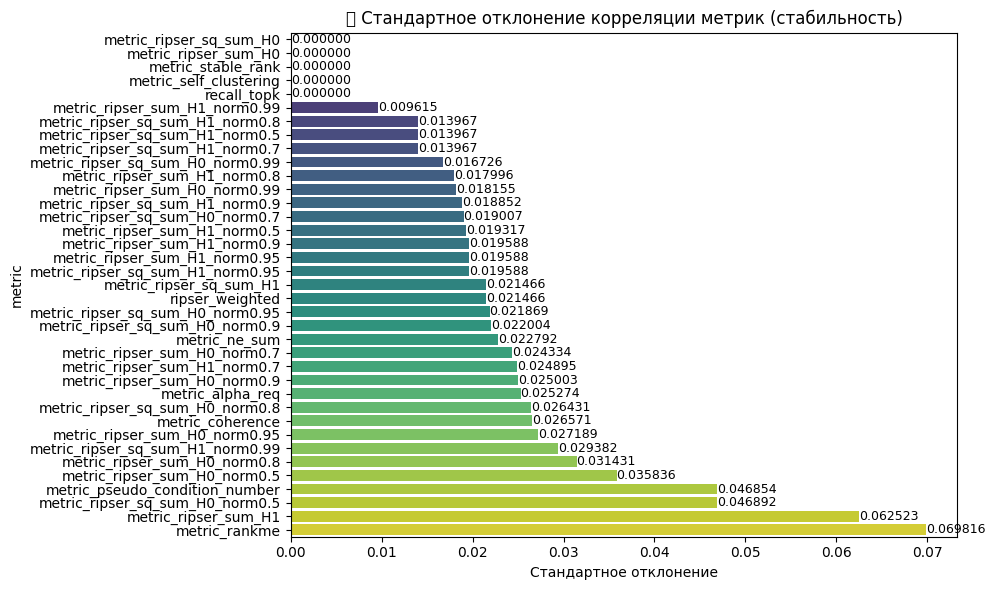

In [45]:
for param in params_cols:
    sorted_std = std_corr[param].sort_values(ascending=True)
    plt.figure(figsize=(10, 6))
    sns.barplot(x=sorted_std.values, y=sorted_std.index, palette="viridis")
    
    for i, v in enumerate(sorted_std.values):
        plt.text(v, i, f"{v:.6f}", color='black', ha='left', va='center', fontsize=9)
    print(param)
    plt.title("📉 Стандартное отклонение корреляции метрик (стабильность)")
    plt.xlabel("Стандартное отклонение")
    plt.tight_layout()
    plt.show()